- we have two types of scaling

  - Z score Standarization

  - min max scalar Normalization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path=r"C:\Users\bhuma\Downloads\Visadataset.csv"
visa_df=pd.read_csv(file_path)

cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns


In [ ]:
# step-1 : calculate take the pwage data
# step-2 : mean of the data
# step-3 : std of the data
# step-4 : nr=data-mean step1-step2
# step-5 :z_wage=nr/std=step4/step3
#stpe-6 : create a new column visa_df['z_wage']=z_wage

In [8]:
wage_data=visa_df['prevailing_wage']
wage_mean=wage_data.mean()
wage_mean

np.float64(74455.81459209183)

In [9]:
wage_std=wage_data.std()
wage_std

52815.94232687357

In [10]:
Nr=wage_data-wage_mean
z_wage=Nr/wage_std
visa_df['z_wage']=z_wage

In [13]:
visa_df[['prevailing_wage','z_wage']]

,prevailing_wage,z_wage
0,592.2029,-1.398510
1,83425.6500,0.169832
2,122996.8600,0.919060
3,83434.0300,0.169991
4,149907.3900,1.428576
...,...,...
25475,77092.5700,0.049923
25476,279174.7900,3.876083
25477,146298.8500,1.360253
25478,86154.7700,0.221504


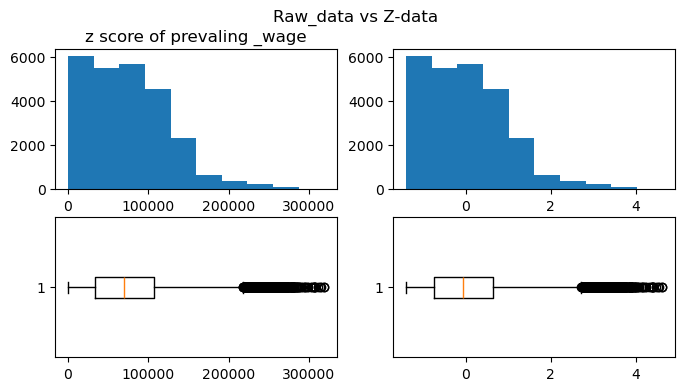

In [18]:
plt.figure(figsize=(8,4))
plt.suptitle('Raw_data vs Z-data')
plt.subplot(2,2,1).hist(wage_data)
plt.title('z score of prevaling _wage')
plt.subplot(2,2,2).hist(z_wage)
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(z_wage,vert=False)
plt.show()

**Standard Scaler**
  
- sklearn

  - preprocessing

    - StandardScalar
  

In [19]:
# step-1 : import method

# step-2 : save the method

# step-3 : apply fit transform

In [20]:
from sklearn.preprocessing import StandardScaler
# save the method
ss=StandardScaler()
#apply fit transform
wage_ss=ss.fit_transform(visa_df[['prevailing_wage']])
visa_df['wage_ss']=wage_ss

In [21]:
visa_df[['prevailing_wage','z_wage','wage_ss']]

,prevailing_wage,z_wage,wage_ss
0,592.2029,-1.398510,-1.398537
1,83425.6500,0.169832,0.169835
2,122996.8600,0.919060,0.919079
3,83434.0300,0.169991,0.169994
4,149907.3900,1.428576,1.428604
...,...,...,...
25475,77092.5700,0.049923,0.049924
25476,279174.7900,3.876083,3.876159
25477,146298.8500,1.360253,1.360280
25478,86154.7700,0.221504,0.221509


In [22]:
visa_df['prevailing_wage']

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [23]:
visa_df['prevailing_wage'].values

array([   592.2029,  83425.65  , 122996.86  , ..., 146298.85  ,
        86154.77  ,  70876.91  ])

In [25]:
visa_df[['prevailing_wage']]

,prevailing_wage
0,592.2029
1,83425.6500
2,122996.8600
3,83434.0300
4,149907.3900
...,...
25475,77092.5700
25476,279174.7900
25477,146298.8500
25478,86154.7700


In [26]:
visa_df['prevailing_wage'].values.reshape(-1,1)

array([[   592.2029],
       [ 83425.65  ],
       [122996.86  ],
       ...,
       [146298.85  ],
       [ 86154.77  ],
       [ 70876.91  ]])

In [27]:
from sklearn.preprocessing import StandardScaler
# save the method
ss=StandardScaler()
#apply fit transform
wage_ss=ss.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))
wage_ss

array([[-1.39853722],
       [ 0.1698353 ],
       [ 0.91907852],
       ...,
       [ 1.36027953],
       [ 0.22150859],
       [-0.06776315]])

**MinMaxSCaler**

In [40]:
#1. read the data
#2.cal min
#3,cal max
#4.nr=1-2
#5.dr=3-2
#6.nr/dr
#7.visa_df[wage_min_max]=nr/dr

In [47]:
wage_data=visa_df['prevailing_wage']
wage_data_min=wage_data.min()
wage_data_max=wage_data.max()
Nr=wage_data-wage_data_min
Dr=wage_data_max-wage_data_min
normalized=Nr/Dr
normalized.max(),normalized.min()


(1.0, 0.0)

In [50]:
from sklearn.preprocessing import MinMaxScaler
# save the method
mm=MinMaxScaler()
#apply fit transform
mm.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))


array([[0.00184853],
       [0.2613452 ],
       [0.385312  ],
       ...,
       [0.45831136],
       [0.26989486],
       [0.22203311]])